In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("raw_datasets/chembl/chembl_hlm_intrinsic.csv")

In [3]:
df

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,standard_relation,standard_value,standard_units,data_validity_comment,activity_comment,assay_type,assay_description,classification_text,classification_bucket
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,47.7,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,4.9,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,16.5,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,8.0,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,6.1,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12132,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12133,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,14.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12134,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12135,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,1.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic


#### Certain assays mention values outside of typical range showing very high HLM CLint values. For this dataset I remove them. Depending on the procedure they can also be kept, if the reason that they are outside of typical range is related to the compounds themselves and not errors from the experimental or procedual side of things

In [4]:
df["data_validity_comment"].unique()

array([nan, 'Outside typical range'], dtype=object)

In [5]:
df_inside_range = df[df["data_validity_comment"].isna()]

In [6]:
df_inside_range

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,standard_relation,standard_value,standard_units,data_validity_comment,activity_comment,assay_type,assay_description,classification_text,classification_bucket
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,47.7,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,4.9,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,16.5,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,8.0,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,6.1,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12132,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12133,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,14.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12134,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
12135,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,1.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic


The ChEMBL retrieved data contains values with various units. While we retain the applicable mL.min-1.kg-1 and mL.min-1.g-1 which we need to scale we drop the remainder, including ml/min.mg due to it only having 5 data points and min.kg/L having 4 data points due to them requiring a separate scaling algorithm most likely

In [7]:
df_inside_range["standard_units"].unique()

array(['mL.min-1.kg-1', 'mL.min-1.g-1', 'nmol/mg/min', 'nM/min/mg',
       'ml/min.mg', 'mg/ml/g', 'min.kg/L', 'hr.Kg/L', 'uL/ml/kg',
       'uL/ml.millig', 'ug ml-1', 'ug/min/mg', 'uL/min', 'ug/min',
       'L/min'], dtype=object)

In [8]:
df_inside_range["standard_units"].value_counts().reindex([
    'mL.min-1.kg-1', 'mL.min-1.g-1', 'nmol/mg/min', 'nM/min/mg',
    'ml/min.mg', 'mg/ml/g', 'min.kg/L', 'hr.Kg/L', 'uL/ml/kg',
    'uL/ml.millig', 'ug ml-1', 'ug/min/mg', 'uL/min', 'ug/min',
    'L/min'
], fill_value=0)

standard_units
mL.min-1.kg-1    2843
mL.min-1.g-1     8859
nmol/mg/min        10
nM/min/mg           1
ml/min.mg           5
mg/ml/g             1
min.kg/L            4
hr.Kg/L            33
uL/ml/kg           21
uL/ml.millig       10
ug ml-1            36
ug/min/mg           9
uL/min             17
ug/min              2
L/min              69
Name: count, dtype: int64

In [9]:
df_inside_range = df_inside_range[
    df_inside_range["standard_units"].isin([
        "mL.min-1.kg-1",
        "mL.min-1.g-1",
    ])
].reset_index(drop=True)

In [10]:
df_inside_range

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,standard_relation,standard_value,standard_units,data_validity_comment,activity_comment,assay_type,assay_description,classification_text,classification_bucket
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,47.7,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,4.9,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,16.5,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,8.0,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,6.1,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11697,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11698,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,14.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11699,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11700,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,1.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic


We also need to drop the 0 value data points due to them influencing log10 and with the OpenADMET not having 0 cases

In [11]:
df_inside_range

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,standard_relation,standard_value,standard_units,data_validity_comment,activity_comment,assay_type,assay_description,classification_text,classification_bucket
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,47.7,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,4.9,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,16.5,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,8.0,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,=,6.1,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11697,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11698,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,14.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11699,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,12.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic
11700,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,=,1.0,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic


In [12]:
df_inside_range["hlm_value_unscaled"] = df_inside_range["standard_value"]

# true log10, zeros become NaN
df_inside_range["hlm_value_unscaled_log10_nan"] = np.where(
    df_inside_range["hlm_value_unscaled"] > 0,
    np.log10(df_inside_range["hlm_value_unscaled"]),
    np.nan
)

# epsilon only for exact zeros
epsilon = 1e-1
df_inside_range["hlm_value_unscaled_log10_epsilon"] = np.where(
    df_inside_range["hlm_value_unscaled"] == 0,
    np.log10(epsilon),
    np.log10(df_inside_range["hlm_value_unscaled"])
)


C:\Users\talag\anaconda3\envs\prolif_312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\talag\anaconda3\envs\prolif_312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
df_inside_range

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,...,standard_units,data_validity_comment,activity_comment,assay_type,assay_description,classification_text,classification_bucket,hlm_value_unscaled,hlm_value_unscaled_log10_nan,hlm_value_unscaled_log10_epsilon
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,47.7,1.678518,1.678518
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,4.9,0.690196,0.690196
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,16.5,1.217484,1.217484
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,8.0,0.903090,0.903090
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,mL.min-1.kg-1,NaN,NaN,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,6.1,0.785330,0.785330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11697,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,12.0,1.079181,1.079181
11698,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,14.0,1.146128,1.146128
11699,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,12.0,1.079181,1.079181
11700,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,mL.min-1.g-1,NaN,NaN,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,1.0,0.000000,0.000000


In [14]:
import numpy as np

df_inside_range["hlm_value_scaled"] = np.where(
    df_inside_range["standard_units"] == "mL.min-1.g-1",
    df_inside_range["standard_value"] * 1.028,
    df_inside_range["standard_value"]
)

# true log10, zeros become NaN
df_inside_range["hlm_value_scaled_log10_nan"] = np.where(
    df_inside_range["hlm_value_scaled"] > 0,
    np.log10(df_inside_range["hlm_value_scaled"]),
    np.nan
)

# epsilon only for exact zeros
epsilon = 1e-1
df_inside_range["hlm_value_scaled_log10_epsilon"] = np.where(
    df_inside_range["hlm_value_scaled"] == 0,
    np.log10(epsilon),
    np.log10(df_inside_range["hlm_value_scaled"])
)


C:\Users\talag\anaconda3\envs\prolif_312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\talag\anaconda3\envs\prolif_312\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [15]:
df_inside_range

,activity_id,molecule_chembl_id,smiles,structure_status,target_chembl_id,target_name,assay_chembl_id,document_chembl_id,data_year,standard_type,...,assay_type,assay_description,classification_text,classification_bucket,hlm_value_unscaled,hlm_value_unscaled_log10_nan,hlm_value_unscaled_log10_epsilon,hlm_value_scaled,hlm_value_scaled_log10_nan,hlm_value_scaled_log10_epsilon
0,33031,CHEMBL306457,NC(=O)C(C[C@H](O)[C@H](Cc1ccccc1)NC(=O)c1cnc2c...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,47.7,1.678518,1.678518,47.700,1.678518,1.678518
1,34270,CHEMBL66457,CC(C)(O)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,4.9,0.690196,0.690196,4.900,0.690196,0.690196
2,34274,CHEMBL304053,CC(C)(O)CCC(C[C@H](O)[C@H](Cc1ccccc1F)NC(=O)c1...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,16.5,1.217484,1.217484,16.500,1.217484,1.217484
3,35507,CHEMBL68366,CC(C)(F)CC[C@H](C[C@H](O)[C@H](Cc1ccccc1)NC(=O...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,8.0,0.903090,0.903090,8.000,0.903090,0.903090
4,39099,CHEMBL303673,O=C(N[C@@H](Cc1ccccc1)[C@@H](O)CC(C(=O)NO)C1CC...,smiles_found,CHEMBL372,Homo sapiens,CHEMBL695026,CHEMBL1147552,2004.0,CL,...,F,In vitro oxidative metabolic stability measure...,in vitro oxidative metabolic stability measure...,chembl_hlm_intrinsic,6.1,0.785330,0.785330,6.100,0.785330,0.785330
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11697,26316940,CHEMBL5712066,C=CC(=O)Nc1ccc(C(=O)NC2CCN(Cc3ccc(-c4nc5cc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,12.0,1.079181,1.079181,12.336,1.091174,1.091174
11698,26316941,CHEMBL2325741,NC1(C(=O)N[C@@H](CCO)c2ccc(Cl)cc2)CCN(c2nc[nH]...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,14.0,1.146128,1.146128,14.392,1.158121,1.158121
11699,26316942,CHEMBL2177390,CC(C)NC[C@@H](C(=O)N1CCN(c2ncnc3c2[C@H](C)C[C@...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,12.0,1.079181,1.079181,12.336,1.091174,1.091174
11700,26316943,CHEMBL1079175,NC1(c2ccc(-c3nc4ccn5c(=O)[nH]nc5c4cc3-c3ccccc3...,smiles_found,CHEMBL612558,ADMET,CHEMBL5712039,CHEMBL5705908,2019.0,CL,...,A,Microsomal stability in human liver microsome ...,microsomal stability in human liver microsome ...,chembl_hlm_intrinsic,1.0,0.000000,0.000000,1.028,0.011993,0.011993


Let's plot to see the results

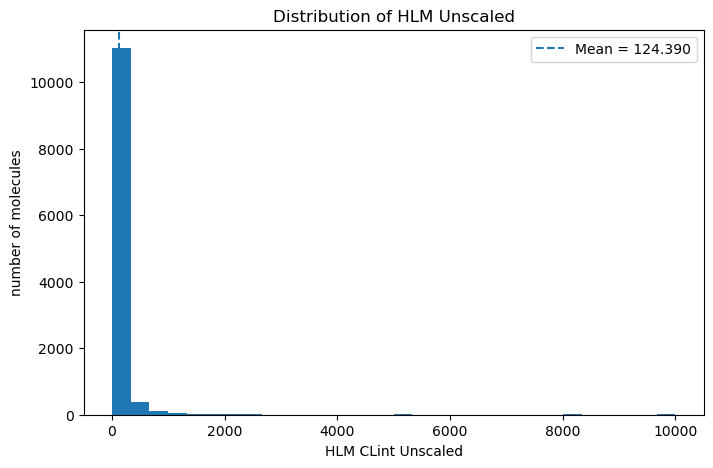

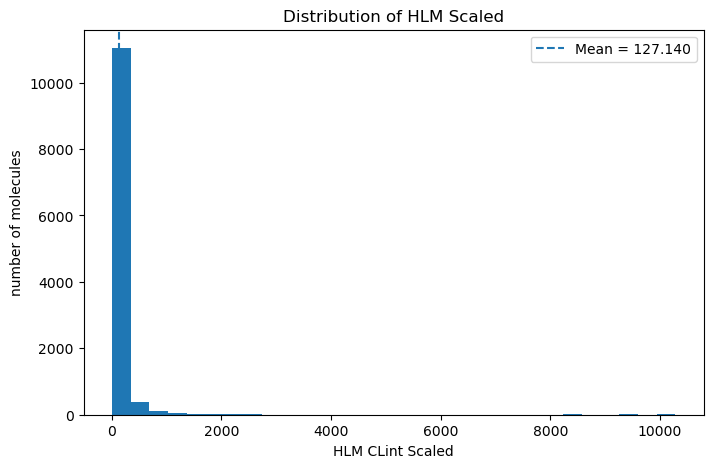

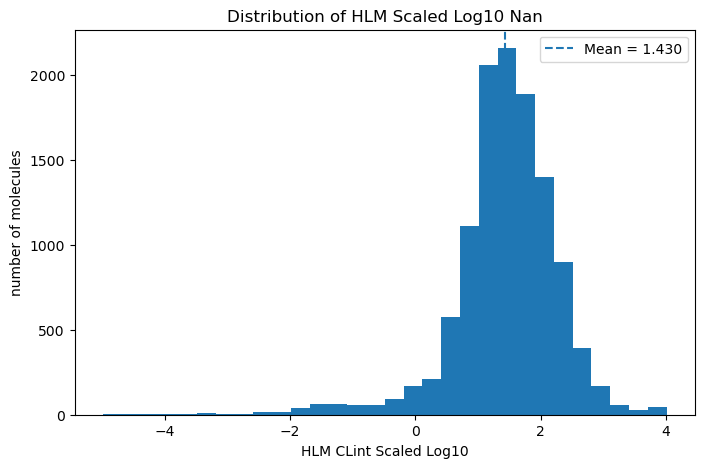

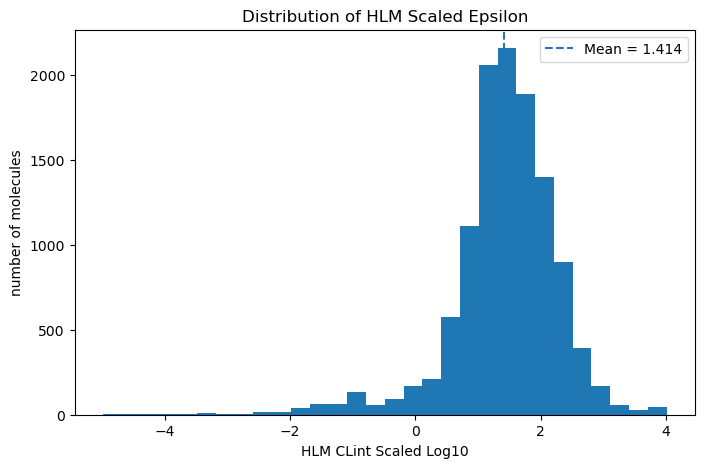

In [16]:
import matplotlib.pyplot as plt

# Mean values
mean_unscaled = df_inside_range["hlm_value_unscaled"].mean()
mean_scaled = df_inside_range["hlm_value_scaled"].mean()
mean_scaled_log10_nan = df_inside_range["hlm_value_scaled_log10_nan"].mean()
mean_scaled_log10_epsilon = df_inside_range["hlm_value_scaled_log10_epsilon"].mean()

# Plot 1: unscaled
plt.figure(figsize=(8, 5))
plt.hist(df_inside_range["hlm_value_unscaled"], bins=30)
plt.axvline(mean_unscaled, linestyle="--", label=f"Mean = {mean_unscaled:.3f}")
plt.xlabel("HLM CLint Unscaled")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Unscaled")
plt.legend()
plt.show()

# Plot 2: scaled
plt.figure(figsize=(8, 5))
plt.hist(df_inside_range["hlm_value_scaled"], bins=30)
plt.axvline(mean_scaled, linestyle="--", label=f"Mean = {mean_scaled:.3f}")
plt.xlabel("HLM CLint Scaled")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Scaled")
plt.legend()
plt.show()

# Plot 3: log10 scaled Nan
plt.figure(figsize=(8, 5))
plt.hist(df_inside_range["hlm_value_scaled_log10_nan"], bins=30)
plt.axvline(mean_scaled_log10_nan, linestyle="--", label=f"Mean = {mean_scaled_log10_nan:.3f}")
plt.xlabel("HLM CLint Scaled Log10")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Scaled Log10 Nan")
plt.legend()
plt.show()

# Plot 4: log10 scaled epsilon
plt.figure(figsize=(8, 5))
plt.hist(df_inside_range["hlm_value_scaled_log10_epsilon"], bins=30)
plt.axvline(mean_scaled_log10_epsilon, linestyle="--", label=f"Mean = {mean_scaled_log10_epsilon:.3f}")
plt.xlabel("HLM CLint Scaled Log10")
plt.ylabel("number of molecules")
plt.title("Distribution of HLM Scaled Epsilon")
plt.legend()
plt.show()

In [17]:
df_inside_range["dataset"] = "chembl_dataset"
df_inside_range.to_csv("adjusted_datasets/chembl_hlm_adjusted.csv")